#### ML

Construimos 3 modelos de decisión para el dataset Iris. Partición 60-40, validación k-fold, matriz de confusión y métricas

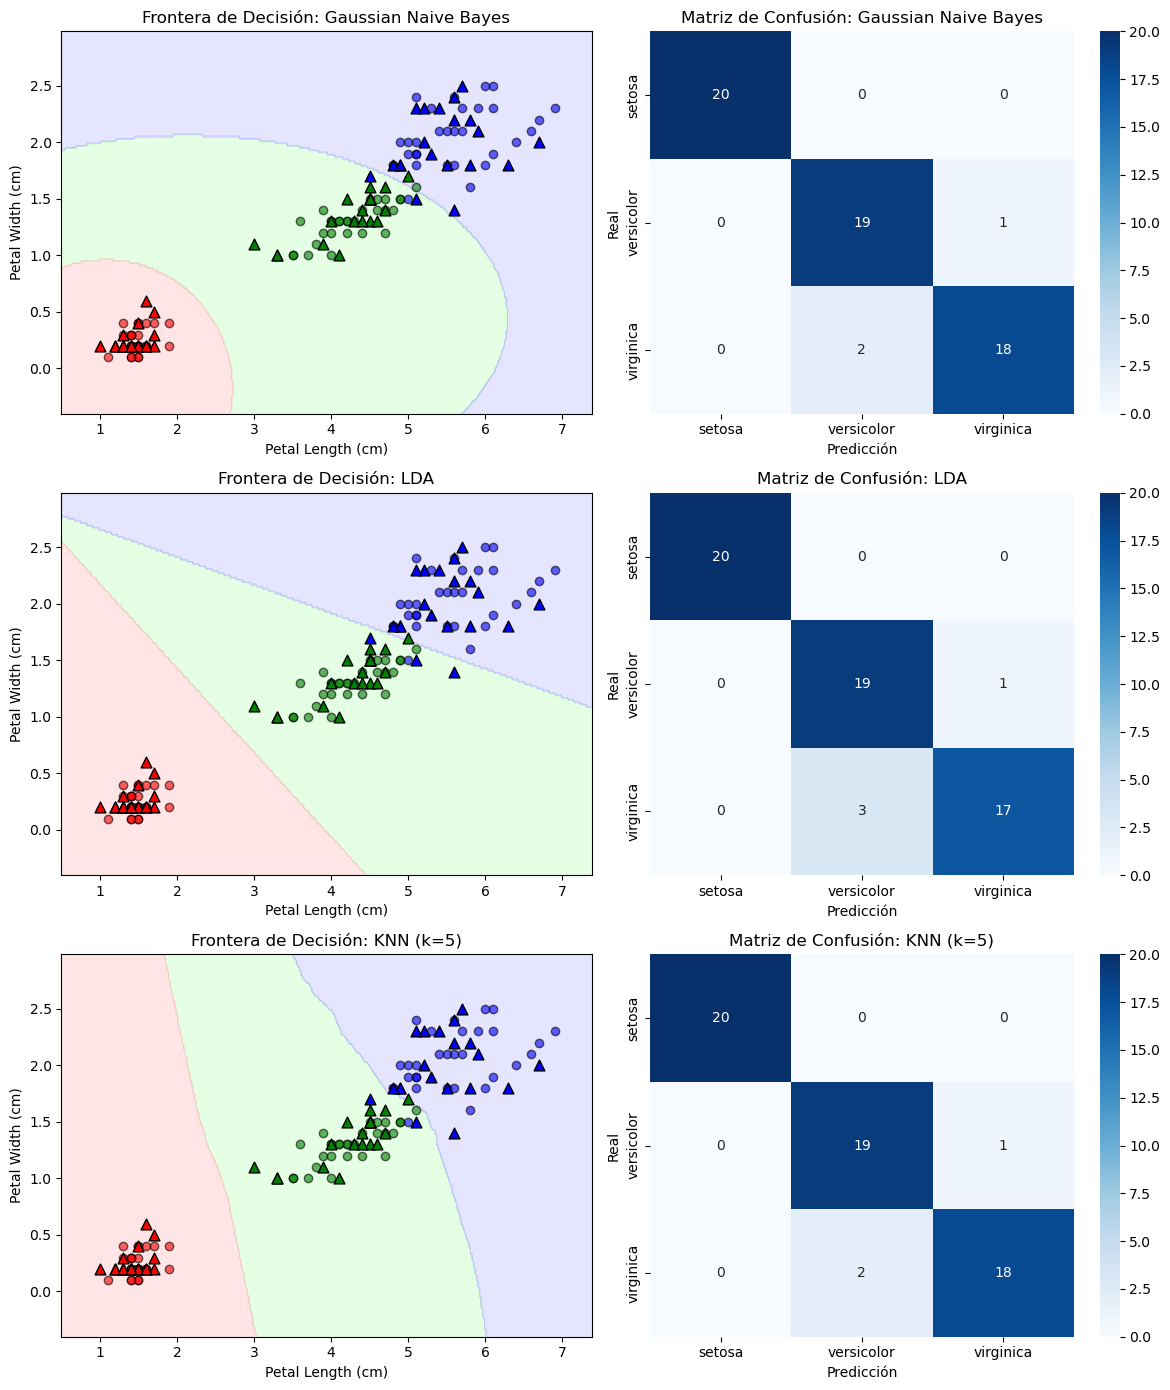

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from matplotlib.colors import ListedColormap

# 1. Carga del dataset Iris utilizando largo y ancho del pétalo
iris = load_iris()
X = iris.data[:, [2, 3]]
y = iris.target
target_names = iris.target_names

# 2. División 60% entrenamiento / 40% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)

# 3. Definición de modelos
models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# 4. Validación Cruzada Stratified K-Fold (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Configuración de figuras y evaluación
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
cmap_bg = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
colors = ['red', 'green', 'blue']

for idx, (name, model) in enumerate(models.items()):
    # Validación Cruzada K-Fold en Train (60%)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Ajuste en entrenamiento y evaluación en test (40%)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # --- Visualización de Fronteras de Decisión ---
    ax_bound = axes[idx, 0]
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax_bound.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    
    for i, col in zip(range(3), colors):
        ax_bound.scatter(X_train[y_train == i, 0], X_train[y_train == i, 1], c=col, alpha=0.6, edgecolors='k')
        ax_bound.scatter(X_test[y_test == i, 0], X_test[y_test == i, 1], c=col, marker='^', s=60, edgecolors='k')
        
    ax_bound.set_title(f"Frontera de Decisión: {name}")
    ax_bound.set_xlabel("Petal Length (cm)")
    ax_bound.set_ylabel("Petal Width (cm)")
    
    # --- Matriz de Confusión ---
    ax_cm = axes[idx, 1]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax_cm)
    ax_cm.set_title(f"Matriz de Confusión: {name}")
    ax_cm.set_xlabel("Predicción")
    ax_cm.set_ylabel("Real")

plt.tight_layout()
plt.show()

Ahora partición 15/85% KNN con k=9, y k fold con k=20

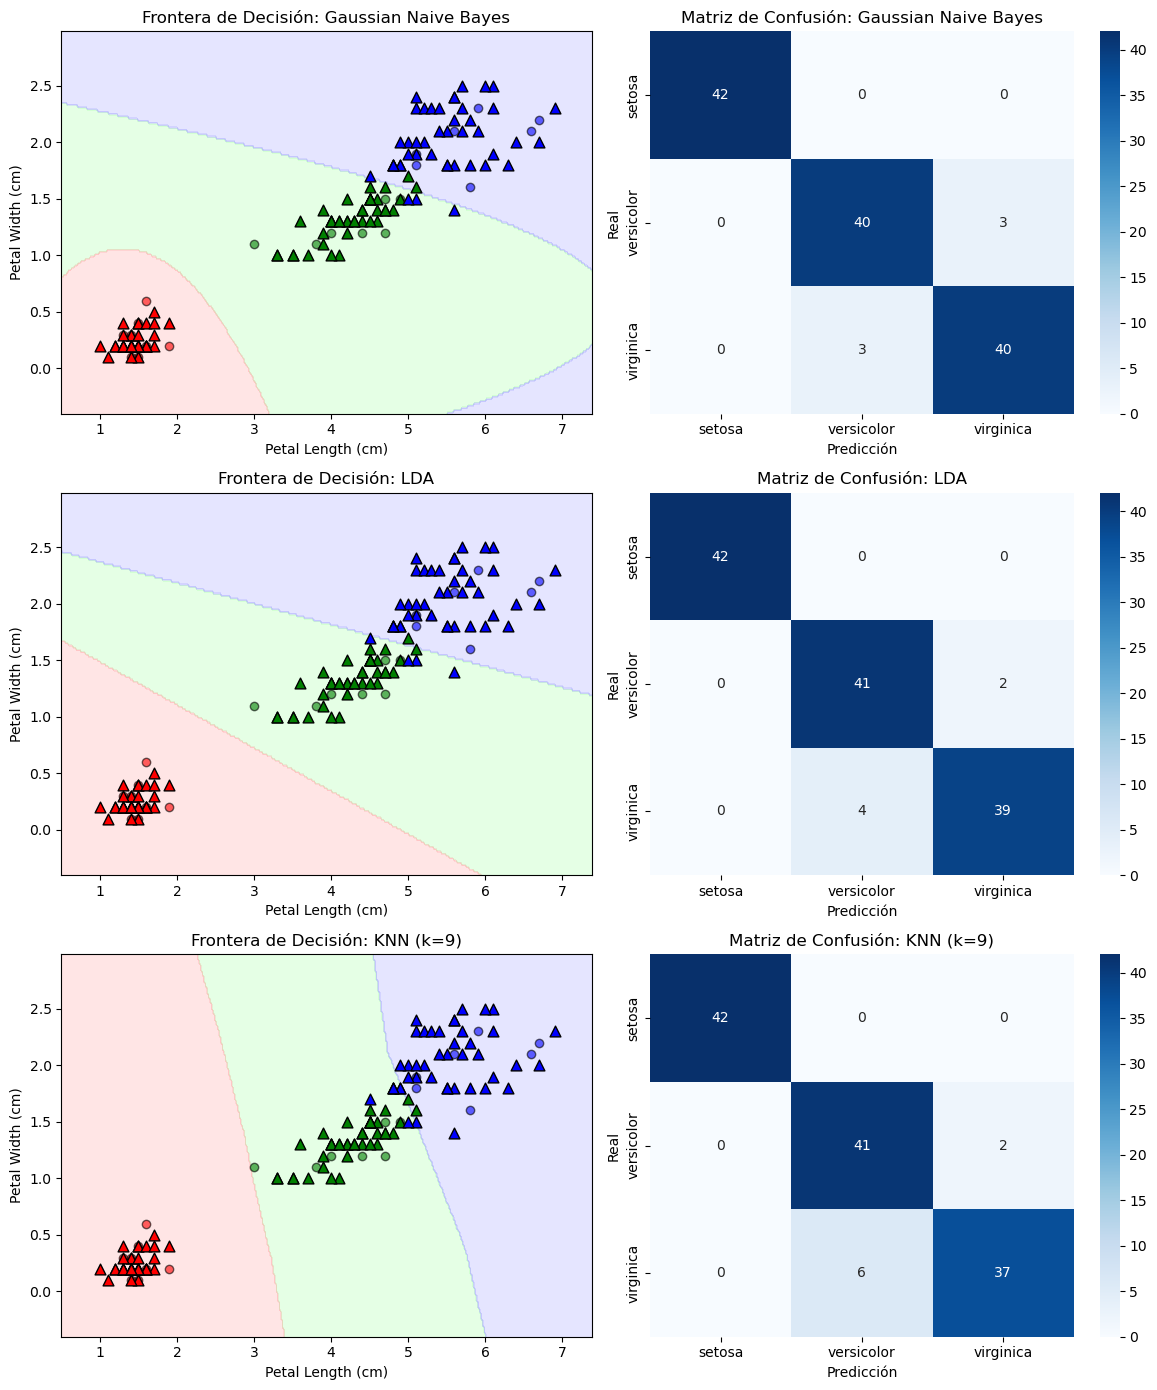

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from matplotlib.colors import ListedColormap

# 1. Carga del dataset Iris utilizando largo y ancho del pétalo
iris = load_iris()
X = iris.data[:, [2, 3]]
y = iris.target
target_names = iris.target_names

# 2. División 60% entrenamiento / 40% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.85, random_state=42, stratify=y
)

# 3. Definición de modelos
models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "KNN (k=9)": KNeighborsClassifier(n_neighbors=9)
}

# 4. Validación Cruzada Stratified K-Fold (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Configuración de figuras y evaluación
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
cmap_bg = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
colors = ['red', 'green', 'blue']

for idx, (name, model) in enumerate(models.items()):
    # Validación Cruzada K-Fold en Train (60%)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Ajuste en entrenamiento y evaluación en test (40%)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # --- Visualización de Fronteras de Decisión ---
    ax_bound = axes[idx, 0]
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax_bound.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    
    for i, col in zip(range(3), colors):
        ax_bound.scatter(X_train[y_train == i, 0], X_train[y_train == i, 1], c=col, alpha=0.6, edgecolors='k')
        ax_bound.scatter(X_test[y_test == i, 0], X_test[y_test == i, 1], c=col, marker='^', s=60, edgecolors='k')
        
    ax_bound.set_title(f"Frontera de Decisión: {name}")
    ax_bound.set_xlabel("Petal Length (cm)")
    ax_bound.set_ylabel("Petal Width (cm)")
    
    # --- Matriz de Confusión ---
    ax_cm = axes[idx, 1]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax_cm)
    ax_cm.set_title(f"Matriz de Confusión: {name}")
    ax_cm.set_xlabel("Predicción")
    ax_cm.set_ylabel("Real")

plt.tight_layout()
plt.show()

Ejercicio 3: Regresión

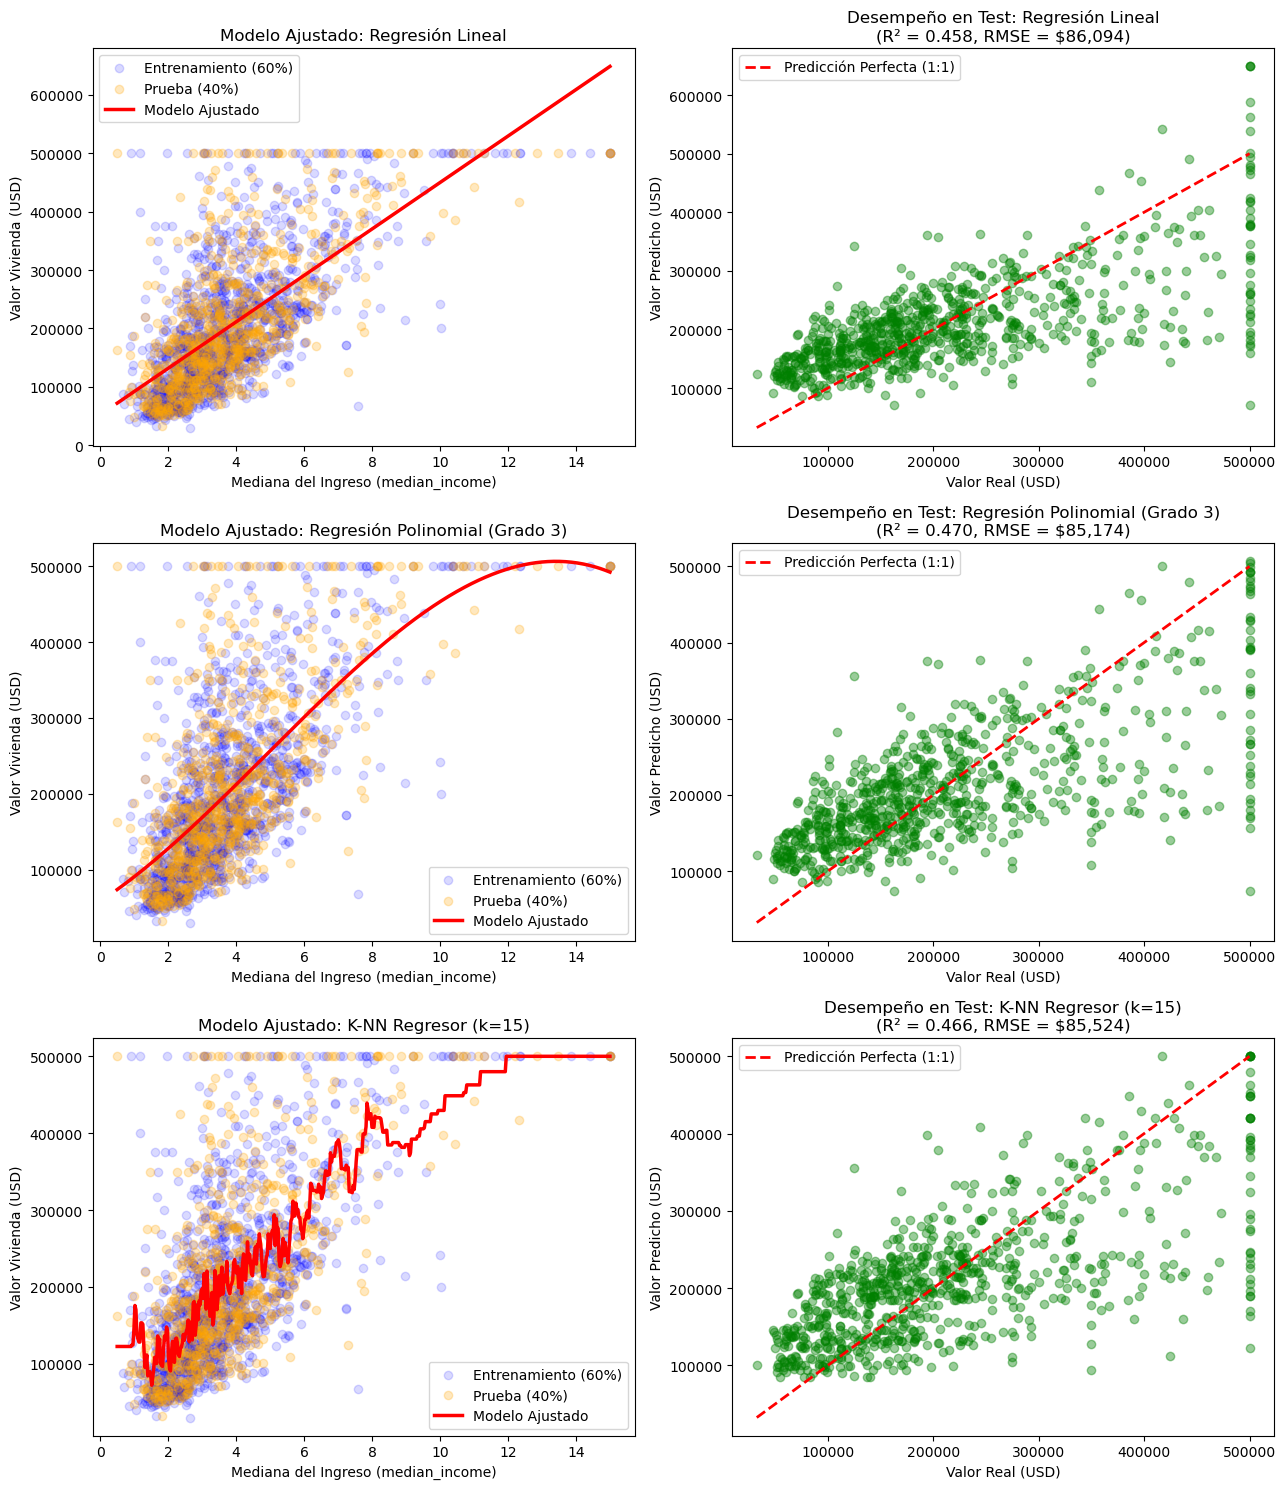


--- RESUMEN DE MÉTRICAS ---
                               CV R² (Mean ± Std)   CV RMSE Test R² Test RMSE  Test MAE
Regresión Lineal                  0.4384 ± 0.0529  85268.24  0.4584  86094.49  63673.56
Regresión Polinomial (Grado 3)    0.4437 ± 0.0606  84797.03  0.4699  85174.25  62570.63
K-NN Regresor (k=15)              0.4011 ± 0.0608  88022.83  0.4656  85524.23  63343.91


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Carga del dataset California Housing directamente desde repositorio público
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df_housing = pd.read_csv(url)

# 2. Separación en X_raw e y_raw
X_raw = df_housing.drop(columns=['median_house_value'])
y_raw = df_housing['median_house_value']

# 3. Selección de atributo clave para visualización 2D (Mediana de Ingresos -> median_income)
# Para este ejemplo se toma una muestra limpia de 2000 datos para facilitar la renderización
np.random.seed(42)
sample_idx = np.random.choice(len(df_housing), size=2000, replace=False)

X_single = X_raw[['median_income']].iloc[sample_idx]
y_single = y_raw.iloc[sample_idx]

# 4. Partición 60% Entrenamiento / 40% Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_single, y_single, test_size=0.40, random_state=42
)

# 5. Definición de modelos de Regresión
models = {
    "Regresión Lineal": LinearRegression(),
    "Regresión Polinomial (Grado 3)": Pipeline([
        ('poly', PolynomialFeatures(degree=3)),
        ('linear', LinearRegression())
    ]),
    "K-NN Regresor (k=15)": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=15))
    ])
}

# 6. Validación Cruzada (5-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 7. Evaluación y Renderizado de Gráficos
fig, axes = plt.subplots(3, 2, figsize=(13, 15))
x_grid = np.linspace(X_single.min().values[0], X_single.max().values[0], 500).reshape(-1, 1)

results = {}

for idx, (name, model) in enumerate(models.items()):
    # Validación Cruzada (R² y RMSE) sobre el 60% de entrenamiento
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    cv_rmse = np.sqrt(-cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error'))
    
    # Entrenamiento y predicción en Test (40%)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {
        "CV R² (Mean ± Std)": f"{cv_r2.mean():.4f} ± {cv_r2.std():.4f}",
        "CV RMSE": f"{cv_rmse.mean():.2f}",
        "Test R²": round(test_r2, 4),
        "Test RMSE": round(test_rmse, 2),
        "Test MAE": round(test_mae, 2)
    }
    
    # --- Gráfico 1: Curva / Modelo Construido ---
    ax_curve = axes[idx, 0]
    ax_curve.scatter(X_train, y_train, color='blue', alpha=0.15, label='Entrenamiento (60%)')
    ax_curve.scatter(X_test, y_test, color='orange', alpha=0.25, label='Prueba (40%)')
    
    y_grid_pred = model.predict(pd.DataFrame(x_grid, columns=['median_income']))
    ax_curve.plot(x_grid, y_grid_pred, color='red', linewidth=2.5, label='Modelo Ajustado')
    
    ax_curve.set_title(f"Modelo Ajustado: {name}")
    ax_curve.set_xlabel("Mediana del Ingreso (median_income)")
    ax_curve.set_ylabel("Valor Vivienda (USD)")
    ax_curve.legend()
    
    # --- Gráfico 2: Desempeño en Prueba (Real vs Predicho) ---
    ax_perf = axes[idx, 1]
    ax_perf.scatter(y_test, y_pred, alpha=0.4, color='green')
    ax_perf.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta (1:1)')
    ax_perf.set_title(f"Desempeño en Test: {name}\n(R² = {test_r2:.3f}, RMSE = ${test_rmse:,.0f})")
    ax_perf.set_xlabel("Valor Real (USD)")
    ax_perf.set_ylabel("Valor Predicho (USD)")
    ax_perf.legend()

plt.tight_layout()
plt.show()

# 8. Mostrar tabla resumida de métricas
df_res = pd.DataFrame(results).T
print("\n--- RESUMEN DE MÉTRICAS ---")
print(df_res.to_string())
